In [ ]:
# Logistic Regression
#1. why we need to move from linear to logistic
#2.why it is called logistic regression
#3.math behind logistic regression
#4.sigmoid function with calculation
#5.understanding m and c  values
#6.confusion matrix
#7.evaluation metrics
#8.end to end logistic regression
#9.real time examples

In [2]:
# 3. MATH BEHIND LOGISTIC REGRESSION
# TELCO CUSTOMER CHURN DATASET
# LINEAR EQUATION
# z = mx + c
#Example
# x = Monthly Charges
# m = weight/coefficient
# c = intercept

m = 2
c = -6

# Example customer monthly charges
x = 4

# Linear equation
z = (m * x) + c

print("m value:", m)
print("c value:", c)
print("x value:", x)
print("z value:", z)

# SIGMOID FUNCTION CALCULATION
import math

# sigmoid formula
sigmoid = 1 / (1 + math.exp(-z))

print("\nSigmoid Probability:", sigmoid)

# CLASSIFICATION
if sigmoid >= 0.5:
    
    print("Prediction : Customer Will Churn (Class 1)")
    
else:
    
    print("Prediction : Customer Will Not Churn (Class 0)")

m value: 2
c value: -6
x value: 4
z value: 2

Sigmoid Probability: 0.8807970779778823
Prediction : Customer Will Churn (Class 1)


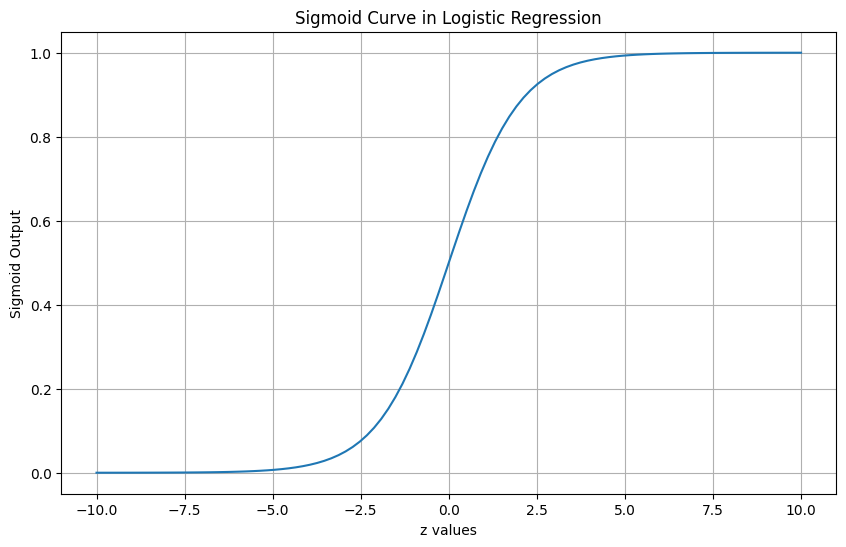

In [3]:
# VISUALIZATION OF SIGMOID CURVE
# TELCO CUSTOMER CHURN DATASET
import matplotlib.pyplot as plt
import numpy as np
# Generate values from -10 to 10
x = np.linspace(-10, 10, 100)
# Sigmoid function
y = 1 / (1 + np.exp(-x))
# Create graph
plt.figure(figsize=(10, 6))
plt.plot(x, y)
# Labels
plt.xlabel('z values')
plt.ylabel('Sigmoid Output')
plt.title('Sigmoid Curve in Logistic Regression')
plt.grid(True)
plt.show()

In [ ]:
#Confusion Matrix
#Actual Predicted  Result 
1           1    True Positive (TP)
1           0    False Negative (FN)
0           1    False Positive (FP)
0           0    True Negative (TN)

In [ ]:
#Evaluation Metrics
Accuracy = (TP + TN) / (TP + TN + FP + FN)
Precision = TP / (TP + FP)
Recall = TP / (TP + FN)
F1 Score = 2 * (Precision * Recall) / (Precision + Recall)

In [8]:
# TELCO CUSTOMER CHURN PREDICTION
# LOGISTIC REGRESSION
# Features  : tenure
# Target    : Churn
# IMPORT LIBRARIES
import numpy as np
import pandas as pd
# LOAD DATASET
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
# DISPLAY FIRST 5 RECORDS
print(df.head())
# SELECT FEATURES AND TARGET
# Feature  : tenure
# Target   : Churn
X = df[['tenure']]
y = df['Churn']
# DISPLAY X AND y
print("\nIndependent Variable (X)")
print(X)
print("\nDependent Variable (y)")
print(y)

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [12]:
import numpy as np
import pandas as pd
import math

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix


# STEP 1: Split data (ensure X and y already exist)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# STEP 2: Create and train model

model = LogisticRegression()
model.fit(X_train, y_train)

# STEP 3: Get m and c values

m = model.coef_[0]
c = model.intercept_[0]

print("m value:", m)
print("c value:", c)

# STEP 4: Manual prediction (example)

x = 5

z = np.dot(m, x) + c
print("\nFor x =", x)
print("z value:", z)

probability = 1 / (1 + np.exp(-z))
print("Probability:", probability)

if probability >= 0.6:
    print("Predicted Class: Customer Will Churn (1)")
else:
    print("Predicted Class: Customer Will Not Churn (0)")


# STEP 5: Model predictions
y_pred = model.predict(X_test)

print("\nPredicted Values:")
print(y_pred)

# STEP 6: Actual vs Predicted
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print("\nActual vs Predicted:")
print(comparison)

# STEP 7: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

tn = cm[0][0]
fp = cm[0][1]
fn = cm[1][0]
tp = cm[1][1]

print("\nTN:", tn, "FP:", fp, "FN:", fn, "TP:", tp)

m value: [-0.03788024]
c value: 0.011110286258821028

For x = 5
z value: [-0.1782909]
Probability: [0.45554497]
Predicted Class: Customer Will Not Churn (0)

Predicted Values:
['No' 'No' 'No' ... 'No' 'No' 'No']

Actual vs Predicted:
     Actual Predicted
185     Yes        No
2715     No        No
3825     No        No
1807    Yes        No
132      No        No
...     ...       ...
6366     No        No
315      No        No
2439     No        No
5002     No        No
1161    Yes        No

[1409 rows x 2 columns]

Confusion Matrix:
[[1035    1]
 [ 373    0]]

TN: 1035 FP: 1 FN: 373 TP: 0


In [13]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

# ACCURACY
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy Score:")
print(accuracy)

# CLASSIFICATION REPORT
report = classification_report(y_test, y_pred)

print("\nClassification Report:")
print(report)


Accuracy Score:
0.7345635202271115

Classification Report:
              precision    recall  f1-score   support

          No       0.74      1.00      0.85      1036
         Yes       0.00      0.00      0.00       373

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409

